In [1]:
import sys

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import numpy as np

sys.path.insert(0,"/software/local/languages/miniforge3/envs/elena/lib/python3.12/site-packages/")

sys.path.insert(0,"/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python3.12/site-packages")

print(sys.path)

import torch
import os
import pickle
import einops

#import plenoptic as po

from model.layers.encoder import *
from model.layers.decoder import *
from model.layers.processor import *
from model.layers.graph_net_block import *
from model.data.dataloader_graphnet import *
from model.data.load_data import *
from model.forecast import GraphSatelliteForecaster
from model.loss_functions import *
from model.evaluation import *

import torch.optim as optim
from sklearn.metrics import mean_squared_error, r2_score
import time
from datetime import datetime
import json
import argparse

import random

%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

import timeit

['/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python3.12/site-packages', '/software/local/languages/miniforge3/envs/elena/lib/python3.12/site-packages/', '/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python312.zip', '/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python3.12', '/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python3.12/lib-dynload', '', '/user/home/ef17148/.local/lib/python3.12/site-packages', '__editable__.openghg_inversions-0.2.0.finder.__path_hook__', '/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python3.12/site-packages']


# Loading the data

The base model just loads all the data from the passed/existing paths, without cropping or applying transforms. use it as a parent class to build specific data objects

### Base class

In [2]:
original_data = LoadBaseSatelliteData(year="2016", region="BRAZIL", month="06", freq=40, verbose=True, load_everything=True)

---- LOADING FOOTPRINTS
Loading footprint data from /group/chemistry/acrg/LPDM/fp_NAME_pre20210701/SOUTHAMERICA/*BRAZIL*SOUTHAMERICA_201606*.nc
reduced the number of datapoints by frequency 40
Loading 48 footprints

 ---- LOADING MET
Loading meteorology from /group/chemistry/acrg/met_archive/UM/SOUTHAMERICA/SOUTHAMERICA_Met_201606*.nc


/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python3.12/site-packages/xarray/core/indexing.py:1443: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]
/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python3.12/site-packages/xarray/core/indexing.py:1443: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True})


---- LOADING TOPOG
trying to load topography from /group/chemistry/acrg/LPDM/topog_NAME/TopogUMG_Mk8_global.nc
---- All done!


In [4]:
original_data.fp_data_full # the footprint file as loaded

<xarray.Dataset>
Dimensions:               (time: 48, lon: 190, lat: 357, lev: 1, height: 20)
Coordinates:
  * time                  (time) datetime64[ns] 2016-06-01T16:03:06 ... 2016-...
  * lon                   (lon) float32 -91.33 -90.98 -90.62 ... -25.15 -24.8
  * lat                   (lat) float32 -60.98 -60.75 -60.51 ... 22.09 22.32
  * lev                   (lev) |S1 b'c'
  * height                (height) float32 500.0 1.5e+03 ... 1.85e+04 1.95e+04
Data variables:
    fp                    (lat, lon, time) float32 dask.array<chunksize=(357, 190, 1), meta=np.ndarray>
    temperature           (time) float32 dask.array<chunksize=(1,), meta=np.ndarray>
    pressure              (time) float32 dask.array<chunksize=(1,), meta=np.ndarray>
    wind_speed            (time) float32 dask.array<chunksize=(1,), meta=np.ndarray>
    wind_direction        (time) float32 dask.array<chunksize=(1,), meta=np.ndarray>
    PBLH                  (time) float32 dask.array<chunksize=(1,), meta=np.ndarray>
    release_lon           (time) float32 dask.array<chunksize=(1,), meta=np.ndarray>
    release_lat           (time) float32 dask.array<chunksize=(1,), meta=np.ndarray>
    particle_locations_n  (height, lon, time) float32 dask.array<chunksize=(20, 190, 1), meta=np.ndarray>
    particle_locations_e  (height, lat, time) float32 dask.array<chunksize=(20, 357, 1), meta=np.ndarray>
    particle_locations_s  (height, lon, time) float32 dask.array<chunksize=(20, 190, 1), meta=np.ndarray>
    particle_locations_w  (height, lat, time) float32 dask.array<chunksize=(20, 357, 1), meta=np.ndarray>
Attributes:
    max_level:  17
    author:     rt17603
    created:    2019-06-01 12:37:14.871106

In [5]:
original_data.met_file # the met file as loaded

<xarray.Dataset>
Dimensions:                              (lat: 357, levels: 20, lon: 239,
                                          time: 720)
Coordinates:
  * lat                                  (lat) float64 -60.98 -60.75 ... 22.32
    sigma                                (levels) float32 dask.array<chunksize=(20,), meta=np.ndarray>
    level_height_0                       (levels) float32 dask.array<chunksize=(20,), meta=np.ndarray>
    sigma_0                              (levels) float32 dask.array<chunksize=(20,), meta=np.ndarray>
  * levels                               (levels) int32 1 3 6 9 ... 48 51 54 57
    level_height                         (levels) float32 dask.array<chunksize=(20,), meta=np.ndarray>
  * lon                                  (lon) float64 -91.33 -90.98 ... -7.553
  * time                                 (time) datetime64[ns] 2016-06-01 ......
Data variables:
    air_pressure                         (levels, lat, lon, time) float32 dask.array<chunksize=(20, 357, 239, 500), meta=np.ndarray>
    air_pressure_at_sea_level            (lat, lon, time) float32 dask.array<chunksize=(357, 239, 500), meta=np.ndarray>
    air_temperature                      (levels, lat, lon, time) float32 dask.array<chunksize=(20, 357, 239, 500), meta=np.ndarray>
    atmosphere_boundary_layer_thickness  (lat, lon, time) float32 dask.array<chunksize=(357, 239, 500), meta=np.ndarray>
    surface_air_pressure                 (lat, lon, time) float32 dask.array<chunksize=(357, 239, 500), meta=np.ndarray>
    surface_upward_sensible_heat_flux    (lat, lon, time) float32 dask.array<chunksize=(357, 239, 500), meta=np.ndarray>
    upward_air_velocity                  (levels, lat, lon, time) float32 dask.array<chunksize=(20, 357, 239, 500), meta=np.ndarray>
    x_wind                               (levels, lat, lon, time) float32 dask.array<chunksize=(20, 357, 239, 500), meta=np.ndarray>
    y_wind                               (levels, lat, lon, time) float32 dask.array<chunksize=(20, 357, 239, 500), meta=np.ndarray>
Attributes:
    source:           Data from Met Office Unified Model
    author:           Elena Fillola (ef17148)
    created:          2022-11-14 13:11
    transformations:  interpolated linearly in space to NAME resolution, inte...

### Square class

the square class cuts the data to a square of size size x size around the measurement coordinates, with the meteorology and topography also aligned to this format

parameters:
- year, month
- region (domain is passed automatically if region is known)
- met_args: dict of shape {"met_levels":list, "met_variables":list} - subsets the meteorology to the passed levels and variables. useful to reduce loading time and memory
- subsetting the data in time: 
    - freq: the final dataset will have approx total_n_footprints/freq samples
    - sampling_mode: "regular" (sampling regularly in time, eg 1 in every freq footprints) or "random" (subsamples n_footprints/freq, time indeces, chosen at random) (default is regular)
- lazy_load: wether to load arrays onto memory, or only lazy-load them. try loading the data then getting the inputs (see below) with and without lazy_load!

In [2]:
cropped_data = LoadSquareSatelliteData(year=2016, region="SAHARA", met_args = {"met_levels":[3, 15]}, freq=20,  size=50, verbose=True, load_everything=True, lazy_load=False)

---- LOADING FOOTPRINTS
Loading footprint data from /group/chemistry/acrg/LPDM/fp_NAME_pre20210701/NORTHAFRICA/*SAHARA*NORTHAFRICA_2016*.nc
there was an error opening the dataset. checking if any of the files are in the bad files list
at least one of the files was in the bad files list, opening with workaround
reduced the number of datapoints by frequency 20
Loading 646 footprints
----- Cutting footprints to square of size 50
careful! We had to pad the footprints along the latitude dimension to extract size 50 (0 and 12 idxs on either side) Padding with nan
33 footprints were at least partially filled with nans because they were cutting outside of the footprint file domain (this is 5.11% of samples)
Padding was needed for the following number of footprints along each direction: {'N': 33, 'S': 0, 'E': 0, 'W': 0}
loading cropped footprint dataset into memory. If you only want to lazy-load, pass load=False

 ---- LOADING MET
Loading meteorology from /group/chemistry/acrg/met_archive/UM/NO

In [7]:
cropped_data.met_file

<xarray.Dataset>
Dimensions:                              (levels: 2, time: 2680, lat: 296,
                                          lon: 320)
Coordinates:
  * levels                               (levels) int32 3 15
  * time                                 (time) datetime64[ns] 2016-01-01 ......
    sigma                                (levels) float32 0.9886 0.8157
    level_height                         (levels) float32 100.0 1.7e+03
  * lat                                  (lat) float64 -7.98 -7.746 ... 61.05
  * lon                                  (lon) float64 -44.02 -43.66 ... 68.27
Data variables:
    air_pressure                         (levels, lat, lon, time) float64 9.6...
    air_pressure_at_sea_level            (lat, lon, time) float64 1.01e+05 .....
    air_temperature                      (levels, lat, lon, time) float64 303...
    atmosphere_boundary_layer_thickness  (lat, lon, time) float64 340.0 ... 1...
    surface_air_pressure                 (lat, lon, time) float64 9.709e+04 ....
    upward_air_velocity                  (levels, lat, lon, time) float64 -0....
    x_wind                               (levels, lat, lon, time) float64 0.0...
    y_wind                               (levels, lat, lon, time) float64 -5....
Attributes:
    author:           Elena Fillola (ef17148)
    created:          2025-03-11 14:37
    transformations:  interpolated linearly in space to NAME resolution

In [16]:
cropped_data.met # met object, interpolated to the same time as the footprints and cropped to the right size

<xarray.Dataset>
Dimensions:                              (levels: 20, lat: 50, lon: 50,
                                          time: 323, time_delta: 1)
Coordinates:
  * levels                               (levels) int32 1 3 6 9 ... 48 51 54 57
    sigma                                (levels) float32 dask.array<chunksize=(20,), meta=np.ndarray>
    level_height                         (levels) float32 dask.array<chunksize=(20,), meta=np.ndarray>
  * time                                 (time) datetime64[ns] 2016-01-01T11:...
  * time_delta                           (time_delta) int64 0
  * lat                                  (lat) int64 0 1 2 3 4 ... 46 47 48 49
  * lon                                  (lon) int64 0 1 2 3 4 ... 46 47 48 49
Data variables: (12/13)
    air_pressure                         (levels, lat, lon, time) float64 dask.array<chunksize=(20, 50, 50, 1), meta=np.ndarray>
    air_pressure_at_sea_level            (lat, lon, time) float64 dask.array<chunksize=(50, 50, 1), meta=np.ndarray>
    air_temperature                      (levels, lat, lon, time) float64 dask.array<chunksize=(20, 50, 50, 1), meta=np.ndarray>
    atmosphere_boundary_layer_thickness  (lat, lon, time) float64 dask.array<chunksize=(50, 50, 1), meta=np.ndarray>
    surface_air_pressure                 (lat, lon, time) float64 dask.array<chunksize=(50, 50, 1), meta=np.ndarray>
    upward_air_velocity                  (levels, lat, lon, time) float64 dask.array<chunksize=(20, 50, 50, 1), meta=np.ndarray>
    ...                                   ...
    y_wind                               (levels, lat, lon, time) float64 dask.array<chunksize=(20, 50, 50, 1), meta=np.ndarray>
    fp_time                              (time) datetime64[ns] 2016-01-01T11:...
    lat_coords                           (time, lat) float64 31.57 ... 21.27
    lon_coords                           (time, lon) float64 20.4 ... 38.35
    wind_angle                           (levels, lat, lon, time) float64 dask.array<chunksize=(20, 50, 50, 1), meta=np.ndarray>
    wind_speed                           (levels, lat, lon, time) float64 dask.array<chunksize=(20, 50, 50, 1), meta=np.ndarray>
Attributes:
    original_met_attrs:  {'author': 'Elena Fillola (ef17148)', 'created': '20...

# Setting up the data

The variables to extract should be passed as follows:
- met_variables: a dict of meteorological variables, of format {"var_name":[list of levels], "surface_var_name":[]}
- static_variables: a list of static variables to add. see `get_static_variables_functions` for a list of valid parameters, or add your own

other parameters:
- time_deltas (list of ints): met is extracted for eahc t-H hours, where H is each item in te list. t=0 (ie the time of the satellite measurement) is extracted automatically. time_deltas=[6,12] extracts the data at t=0, t-6h and t-12h.
- return_asarray (bool, default=False): if false, returns as an xarray dataset. if true, loads into memory as a np array of shape (time, lat*lon, variables)


In [6]:
variables = {"x_wind":[3,15], "y_wind":[3], "surface_air_pressure":[]}
static_variables=["lat_coords", "lon_coords" , "x_coords", "y_coords", "topog", "landcover"]
inputs, input_names = get_square_satellite_inputs(cropped_data, variables, static_variables=static_variables, time_deltas=[24], return_variable_names=True, return_asarray=False)

---Preparing met
extracting met at t-H for H in: [0, 24]
Setting up variables with levels: ['x_wind', 'y_wind']
Setting up surface variables: ['surface_air_pressure']
Setting up static variables: ['lat_coords', 'lon_coords', 'x_coords', 'y_coords', 'topog', 'landcover']
(2, 50, 50)


In [7]:
inputs # the inputs are a stacked DataArray, of dimensions fp_time, lat, lon, and variable
# the inputs are lazy loaded, so they're not actually in memory until you run inputs.load(), 
# or until you attempt to use or extract the values

<xarray.DataArray 'stacked_levels_met' (fp_time: 644, lat: 50, lon: 50,
                                        variable_name: 14)>
array([[[[ 1.04972556e+00, -1.52489440e+00, -2.33737384e+00, ...,
          -2.50000000e+01,  8.75445190e+02,  8.00000000e+00],
         [-3.11886460e-01, -3.26730727e+00, -3.16175422e+00, ...,
          -2.50000000e+01,  8.74448303e+02,  8.00000000e+00],
         [-1.88867450e+00, -3.33596171e+00, -2.34264221e+00, ...,
          -2.50000000e+01,  8.65450928e+02,  8.00000000e+00],
         ...,
         [ 8.17544775e-01, -2.92383185e+00,  8.92668524e-01, ...,
          -2.50000000e+01,  3.34944244e+02,  8.00000000e+00],
         [ 1.55774073e+00, -3.76110165e+00,  1.67271728e-01, ...,
          -2.50000000e+01,  2.91627228e+02,  8.00000000e+00],
         [ 1.61441852e+00, -4.13954466e+00, -1.09304982e-01, ...,
          -2.50000000e+01,  2.56900146e+02,  8.00000000e+00]],

        [[ 1.09267513e+00,  1.19356502e-03, -1.93550241e+00, ...,
          -2.40000000e+01,  1.00430530e+03,  8.00000000e+00],
         [ 1.61553003e-01, -1.70987081e+00, -3.52891742e+00, ...,
          -2.40000000e+01,  9.85129211e+02,  8.00000000e+00],
         [-1.60402985e+00, -2.75743457e+00, -3.19664019e+00, ...,
          -2.40000000e+01,  8.51200195e+02,  8.00000000e+00],
...
         [-3.57202193e+00, -4.14446888e+00, -2.97239169e+00, ...,
           2.30000000e+01,  6.08089417e+02,  8.00000000e+00],
         [-3.69519896e+00, -4.67952809e+00, -4.21642522e+00, ...,
           2.30000000e+01,  6.09794006e+02,  8.00000000e+00],
         [-4.16828970e+00, -5.34043539e+00, -3.34453233e+00, ...,
           2.30000000e+01,  5.89648682e+02,  8.00000000e+00]],

        [[-1.69124721e+00, -3.18584434e+00, -8.96412933e+00, ...,
           2.40000000e+01,  4.34749390e+02,  8.00000000e+00],
         [-1.78971909e+00, -2.74932921e+00, -9.82004109e+00, ...,
           2.40000000e+01,  4.46742859e+02,  8.00000000e+00],
         [-1.32583920e+00, -2.57362776e+00, -1.06174924e+01, ...,
           2.40000000e+01,  5.56187805e+02,  8.00000000e+00],
         ...,
         [-3.49407332e+00, -4.23846372e+00, -2.21319420e+00, ...,
           2.40000000e+01,  6.16419128e+02,  8.00000000e+00],
         [-3.79060419e+00, -4.76628668e+00, -2.37183786e+00, ...,
           2.40000000e+01,  5.94618347e+02,  8.00000000e+00],
         [-4.13148501e+00, -5.27969181e+00, -1.92853997e+00, ...,
           2.40000000e+01,  5.49948242e+02,  8.00000000e+00]]]])
Coordinates:
  * fp_time        (fp_time) datetime64[ns] 2016-01-02T12:04:33.500000 ... 20...
  * lat            (lat) int64 0 1 2 3 4 5 6 7 8 ... 41 42 43 44 45 46 47 48 49
  * lon            (lon) int64 0 1 2 3 4 5 6 7 8 ... 41 42 43 44 45 46 47 48 49
  * variable_name  (variable_name) object MultiIndex
Attributes:
    standard_name:  x_wind
    units:          m s-1
    source:         Data from Met Office Unified Model
    STASH:          [1 0 2]

In [8]:
inputs.variable_name # contains tuples specific to each 2D variable, specifying (variable, level, time_delta)
# surface variables always have level=0, and static variables have level=0 and time_delta=0

<xarray.DataArray 'variable_name' (variable_name: 14)>
array([('y_wind', 3, 0), ('y_wind', 3, 24), ('x_wind', 3, 0),
       ('x_wind', 15, 0), ('x_wind', 3, 24), ('x_wind', 15, 24),
       ('surface_air_pressure', 0, 0), ('surface_air_pressure', 0, 24),
       ('lat_coords', 0, 0), ('lon_coords', 0, 0), ('y_coords', 0, 0),
       ('x_coords', 0, 0), ('topog', 0, 0), ('landcover', 0, 0)], dtype=object)
Coordinates:
  * variable_name  (variable_name) object MultiIndex

In [27]:
input_names # input_names is a dict with the same vaues as inputs.variable_name, but it's easier to search

[{'var': 'y_wind', 'level': 3, 'time_delta': 0, 'type': 'met'},
 {'var': 'y_wind', 'level': 3, 'time_delta': 24, 'type': 'met'},
 {'var': 'x_wind', 'level': 3, 'time_delta': 0, 'type': 'met'},
 {'var': 'x_wind', 'level': 15, 'time_delta': 0, 'type': 'met'},
 {'var': 'x_wind', 'level': 3, 'time_delta': 24, 'type': 'met'},
 {'var': 'x_wind', 'level': 15, 'time_delta': 24, 'type': 'met'},
 {'var': 'surface_air_pressure', 'time_delta': 0, 'type': 'surface_met'},
 {'var': 'surface_air_pressure', 'time_delta': 24, 'type': 'surface_met'},
 {'var': 'lat_coords', 'type': 'static'},
 {'var': 'lon_coords', 'type': 'static'},
 {'var': 'y_coords', 'type': 'static'},
 {'var': 'x_coords', 'type': 'static'},
 {'var': 'topog', 'type': 'static'},
 {'var': 'landcover', 'type': 'static'}]

we can use the xarray dataset to inspect and plot the variable more easily

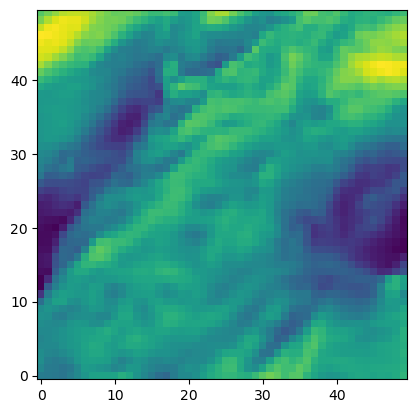

In [23]:
d = inputs.fp_time[1]
plt.imshow(inputs.sel(variable_name=('y_wind', 3, 0), fp_time=d), origin="lower")

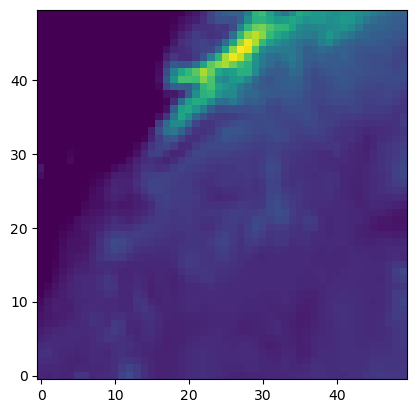

In [22]:
d = inputs.fp_time[1]
plt.imshow(inputs.sel(variable_name=('topog', 0, 0), fp_time=d), origin="lower")

In [ ]:
variables = {"x_wind":[3,15], "y_wind":[3], "surface_air_pressure":[]}
static_variables=["lat_coords", "lon_coords", "x_coords", "y_coords", "topog", "landcover"]
inputs_array, input_names = get_square_satellite_inputs(cropped_data, variables, static_variables=static_variables, time_deltas=[24], return_variable_names=True, return_asarray=True)
# passing return_asarray=True loads the inputs into memory and returns them with the shape (time, lat*lon, variables). might take a while!

In [ ]:
# passing return_asarray=True loads the inputs into memory and returns them with the shape (time, lat*lon, variables)
# this is what the transform function is expecting, but could be improved or avoided!
np.shape(inputs_array)

### Preparing the dataset
FootprintsDataset applies any necessary transforms on the data. the functions used to transform the data are saved in the dataset object. they can be passed to another instance FootprintsDataset (using `test_mode=train_dataset.transform_parameters`), to apply the known transforms to an unseen dataset

In [ ]:
dataset = FootprintsDataset(inputs=inputs, fp=cropped_data.fp_data, input_names=input_names, input_transforms=["clever_transform_3"], output_transforms= ["logv4"])

# Fixed domain data

LoadDomainSatelliteData will load the data over a fixed domain in space, rather than centered around the release point. if we dont specify a domain, it will just load the maximum possible domain.
You can otherwise specify the domain to cut, in latitude and longitude with domain_to_cut (see below)

In [10]:
met_args = {"met_levels":[3, 15]}
data_dom = LoadDomainSatelliteData(year="2016", region="BRAZIL", month="06", freq=40, verbose=True, met_args=met_args)#, domain_to_cut={"lat":[0,20], "lon":[20,40]})

---- LOADING FOOTPRINTS
Loading footprint data from /group/chemistry/acrg/LPDM/fp_NAME_pre20210701/SOUTHAMERICA/*BRAZIL*SOUTHAMERICA_201606*.nc
reduced the number of datapoints by frequency 40
Loading 48 footprints

 ---- LOADING MET
Loading meteorology from /group/chemistry/acrg/met_archive/UM/SOUTHAMERICA/SOUTHAMERICA_Met_201606*.nc

---- LOADING TOPOG
trying to load topography from /group/chemistry/acrg/LPDM/topog_NAME/TopogUMG_Mk8_global.nc
---- All done!
-----CROPPING TO A FIXED DOMAIN
cutting everything to the minimum possible domain: {'lat': [-60.981, 22.323], 'lon': [-91.329, -24.801]}


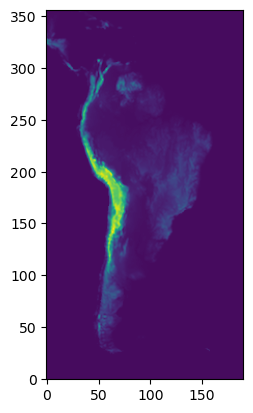

In [11]:
plt.imshow(data_dom.topog.topog, origin="lower")

In [12]:
met_args = {"met_levels":[3, 15]}
data_dom = LoadDomainSatelliteData(year="2016", region="BRAZIL", month="06", freq=40, verbose=True, met_args=met_args, domain_to_cut={"lat":[-20,20]})

---- LOADING FOOTPRINTS
Loading footprint data from /group/chemistry/acrg/LPDM/fp_NAME_pre20210701/SOUTHAMERICA/*BRAZIL*SOUTHAMERICA_201606*.nc
reduced the number of datapoints by frequency 40
Loading 48 footprints

 ---- LOADING MET
Loading meteorology from /group/chemistry/acrg/met_archive/UM/SOUTHAMERICA/SOUTHAMERICA_Met_201606*.nc

---- LOADING TOPOG
trying to load topography from /group/chemistry/acrg/LPDM/topog_NAME/TopogUMG_Mk8_global.nc
---- All done!
-----CROPPING TO A FIXED DOMAIN


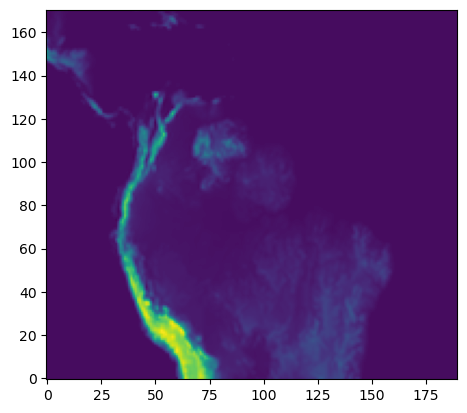

In [13]:
plt.imshow(data_dom.topog.topog, origin="lower")

In [14]:
# the input function works with square data too. note that most of the static variable functions wont work! need to write specific ones
inputs, names = get_square_satellite_inputs(data_dom, {"x_wind":[3,15], "y_wind":[3], "surface_air_pressure":[]}, static_variables=["lat_coords", "topog", "landcover", "landcover_disaggregated"], time_deltas=[100], verbose=True, return_asarray=False, return_variable_names=True)

---Preparing met
extracting met at t-H for H in: [0, 100]
Length before removing indeces: 48
Length after removing indeces: 44
Setting up variables with levels: ['x_wind', 'y_wind']
Setting up surface variables: ['surface_air_pressure']
Setting up static variables: ['lat_coords', 'topog', 'landcover', 'landcover_disaggregated']
<xarray.Dataset>
Dimensions:     (lat: 171, lon: 190, fp_time: 44)
Coordinates:
  * fp_time     (fp_time) datetime64[ns] 2016-06-05T14:57:59 ... 2016-06-30T1...
  * lat         (lat) float64 -19.8 -19.56 -19.33 -19.09 ... 19.51 19.75 19.98
  * lon         (lon) float64 -91.33 -90.98 -90.62 -90.27 ... -25.5 -25.15 -24.8
Data variables:
    lat_coords  (lat, lon, fp_time) float64 -19.8 -19.8 -19.8 ... 19.98 19.98
    lon_coords  (lat, lon, fp_time) float64 -91.33 -91.33 -91.33 ... -24.8 -24.8
Attributes:
    source:           Data from Met Office Unified Model
    author:           Elena Fillola (ef17148)
    created:          2022-11-14 13:11
    transformations:

# sites

loading data for sites works very similarly to satellites

In [2]:
met_datadir = "/group/chemistry/acrg/met_archive/NAME/EUROPE_met/EUROPE_Met_10magl_"
fp_datadir = "/group/chemistry/acrg/LPDM/fp_NAME_pre20210701/EUROPE/MHD-10magl_EUROPE_"

In [3]:
mhd_sq = LoadSquareSiteData(year="2016", site="MHD", month="01", size=100, freq=10, verbose=True, fp_datadir=fp_datadir, met_args={"met_datadir":met_datadir})

---- LOADING FOOTPRINTS
Loading footprint data from /group/chemistry/acrg/LPDM/fp_NAME_pre20210701/EUROPE/MHD-10magl_EUROPE_201601*.nc
reduced the number of datapoints by frequency 10
Loading 75 footprints
----- Cutting footprints to square of size 100

 ---- LOADING MET
Loading meteorology from /group/chemistry/acrg/met_archive/NAME/EUROPE_met/EUROPE_Met_10magl_201601*.nc
----- Cutting met
Error 'Dataset' object has no attribute 'x_wind' happened when adding wind direction and speed to met. Could be a naming error!

---- LOADING TOPOG
trying to load topography from /group/chemistry/acrg/LPDM/topog_NAME/TopogUMG_Mk8_global.nc
----- Cutting topog
---- All done!


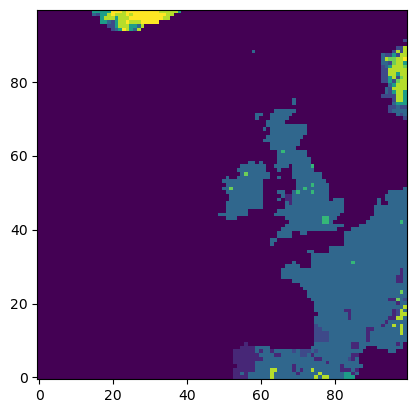

In [22]:
plt.imshow(mhd_sq.topog.landcover.sel(time=mhd_sq.topog.topog.time[0]), origin="lower")

In [3]:
mhd_dom = LoadDomainSiteData(year="2016", site="MHD", month="01", freq=10, verbose=True, fp_datadir=fp_datadir, met_args={"met_datadir":met_datadir})

---- LOADING FOOTPRINTS
Loading footprint data from /group/chemistry/acrg/LPDM/fp_NAME_pre20210701/EUROPE/MHD-10magl_EUROPE_201601*.nc


reduced the number of datapoints by frequency 10
Loading 75 footprints

 ---- LOADING MET
Loading meteorology from /group/chemistry/acrg/met_archive/NAME/EUROPE_met/EUROPE_Met_10magl_201601*.nc

---- LOADING TOPOG
trying to load topography from /group/chemistry/acrg/LPDM/topog_NAME/TopogUMG_Mk8_global.nc
---- All done!
-----CROPPING TO A FIXED DOMAIN
cutting everything to the minimum possible domain: {'lat': [10.729, 79.057], 'lon': [-97.9, 39.38]}
Error 'Dataset' object has no attribute 'x_wind' happened when adding wind direction and speed to met. Could be a naming error!


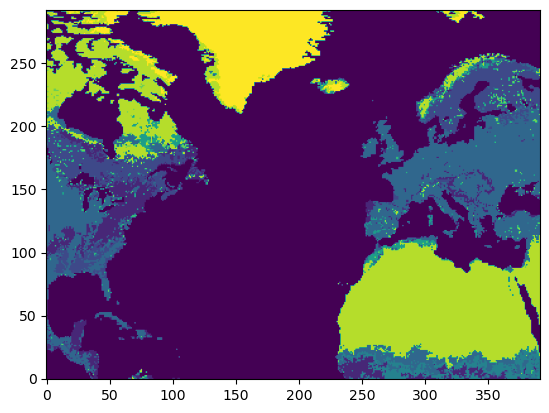

In [5]:
plt.imshow(mhd_dom.topog.landcover, origin="lower")

In [6]:
mhd_dom.met

<xarray.Dataset>
Dimensions:             (lat: 293, lon: 391, time: 75, time_delta: 1)
Coordinates:
  * lat                 (lat) float64 10.73 10.96 11.2 ... 78.59 78.82 79.06
  * lon                 (lon) float64 -97.9 -97.55 -97.2 ... 38.68 39.03 39.38
  * time                (time) datetime64[ns] 2016-01-01 ... 2016-01-31T20:00:00
  * time_delta          (time_delta) int64 0
Data variables:
    Temperature         (lat, lon, time) float32 dask.array<chunksize=(293, 391, 75), meta=np.ndarray>
    PBLH                (lat, lon, time) float32 dask.array<chunksize=(293, 391, 75), meta=np.ndarray>
    Pressure            (lat, lon, time) float32 dask.array<chunksize=(293, 391, 75), meta=np.ndarray>
    Sea_level_pressure  (lat, lon, time) float32 dask.array<chunksize=(293, 391, 75), meta=np.ndarray>
    Wind_Speed          (lat, lon, time) float32 dask.array<chunksize=(293, 391, 75), meta=np.ndarray>
    Wind_Direction      (lat, lon, time) float32 dask.array<chunksize=(293, 391, 75), meta=np.ndarray>
    fp_time             (time) datetime64[ns] 2016-01-01 ... 2016-01-31T20:00:00

can also get the inputs using the same function - note that at the moment, these regions have met only at 10magl (ie at a single level) and therefore should be treated like surface variables

In [ ]:
inputs, names = get_square_satellite_inputs(mhd_sq, {"Wind_Speed":[], "Temperature":[]}, static_variables=["lat_coords", "topog", "landcover", "landcover_disaggregated"], time_deltas=[100], verbose=True, return_asarray=False, return_variable_names=True)

Evaluating the outputs of the model

In [7]:
fluxes_og = xr.open_dataset("/group/chemistry/acrg/Gridded_fluxes/CH4/EDGAR_v6.0/yearly/v6.0_CH4_2016_TOTALS.0.1x0.1.nc")
#
fluxes_og.coords['lon'] = (fluxes_og.coords['lon'] + 180) % 360 - 180
fluxes_og = fluxes_og.sortby(fluxes_og.lon)
fluxes = fluxes_og.sel(lat=mhd_sq.site_fp_lats, lon= mhd_sq.site_fp_lons, method="nearest")
fluxes = fluxes.emi_ch4.values

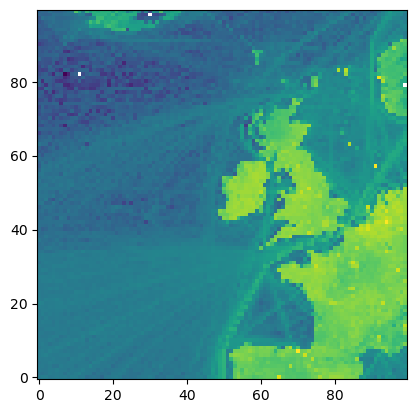

In [9]:
plt.imshow(np.log10(fluxes), origin="lower")

In [15]:
def predict_fluxes(fps, predictions, flux, units_transform = None):
    """
    convolute predicted footprints and fluxes.
    Returns two np arrays, one with the true flux and one with the emulated flux, both of shape (n_footprints,)
    input flux should be an array, regridded and cut to the same resolution and size of the footprints
    units_transform can be None (use fluxes directly), "default" (performs flux*1e3 / CH4molarmass) or another function (which should return an array of the same shape as the original flux)
    """
    if units_transform != None:
        if units_transform == "default":
            molarmass = 16.0425
            flux = flux*1e3 / molarmass
        else:
            flux = units_transform(flux)
    flux = flux.flatten()
    true_concentration = fps*flux
    true_flux = np.sum(true_concentration, axis = (1))
    pred_concentration = predictions*flux
    pred_flux = np.sum(pred_concentration, axis = (1))
    
    return true_flux, pred_flux

In [46]:
noisy_fps = mhd_sq.fp_data * np.random.normal(1.2,1, np.shape(mhd_sq.fp_data)) 

In [47]:
true_flux, pred_flux = predict_fluxes(mhd_sq.fp_data, noisy_fps, fluxes, units_transform=None)

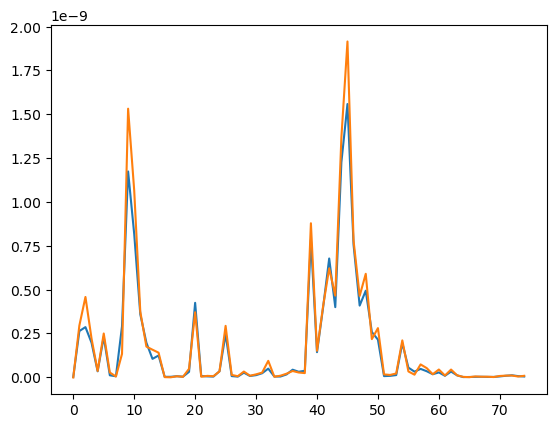

In [ ]:
plt.plot(true_flux)
plt.plot(pred_flux)